# Sollertia Forgery — interactive analysis notebook

Temporary, will be removed soon.

## 1. Setup

In [ ]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

from dataclasses import dataclass
from itertools import groupby
from pathlib import Path

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle

from sollertia_forgery.shared_assets import DatasetData, TrialGeometry
from sollertia_forgery.analysis import (
    DriftCellColumn,
    DriftDetectionConfiguration,
    TuningColumn,
    TuningReport,
    plot_drift_profile_categories,
    plot_drift_vs_bleaching,
    plot_place_cell_heatmap,
    plot_population_activity_by_position,
    plot_population_vector_correlation_vs_lag,
    plot_rate_map_heatmap,
    plot_recurrence_probability_vs_lag,
    plot_reference_day_sorted_rate_maps,
    plot_sessions_active_distribution,
)
from sollertia_forgery.analysis.drift import compute_drift_report

## 2. Configuration

Single-animal focus on **animal 11**. Pick a session via `SESSION_INDEX` (0-based into the chronological session list); set `TRIAL_TYPE` to override the default first-trial-type pick. Reward-shift constants below are void-specific (cyclic_4_cue, 240 cm track).

In [2]:
DATASET_PATH = Path("/home/data/Data/void")
ANIMAL = "11"
SESSION_INDEX = 0  # 0-based index into the animal's chronologically sorted sessions
TRIAL_TYPE: str | None = None  # None -> use the first trial type in the report

DRIFT_CONFIG = DriftDetectionConfiguration(peak_shift_shuffle_count=200)

# void reward-shift constants (cyclic_4_cue, 240-cm track).
TRACK_LENGTH_CM = 240.0
OLD_REWARD_LO, OLD_REWARD_HI = 218.0, 232.0
NEW_REWARD_LO, NEW_REWARD_HI = 98.0, 109.0
SHIFT_AT_SESSION = 15
PRE_SHIFT_SESSIONS = tuple(range(0, SHIFT_AT_SESSION))
PANEL_SESSIONS = (14, 15, 16, 17, 18, 19)
ANCHOR_WINDOW_SESSIONS = 15
PROXIMITY_CM = 30.0

In [3]:
dataset = DatasetData.load(dataset_path=DATASET_PATH)
animal = dataset.get_animal(animal=ANIMAL)
sessions = tuple(
    sorted(dataset.get_sessions_for_animal(animal=ANIMAL), key=lambda dataset_session: dataset_session.session)
)
session = sessions[SESSION_INDEX]

print(f"Dataset:  {dataset.name} ({len(dataset.sessions)} sessions, {len(dataset.animals)} animals)")
print(f"Animal:   {ANIMAL}  ({len(sessions)} sessions)")
print(f"Session:  [{SESSION_INDEX}] {session.session}")

Dataset:  void (55 sessions, 3 animals)
Animal:   11  (20 sessions)
Session:  [0] 2025-07-21-15-47-38-718925


## 3. Tuning (place only)

In [ ]:
tuning_report = TuningReport.load(session=session)
trial_type = TRIAL_TYPE if TRIAL_TYPE is not None else tuning_report.summary.trial_types[0]
print(f"Trial type: {trial_type}")

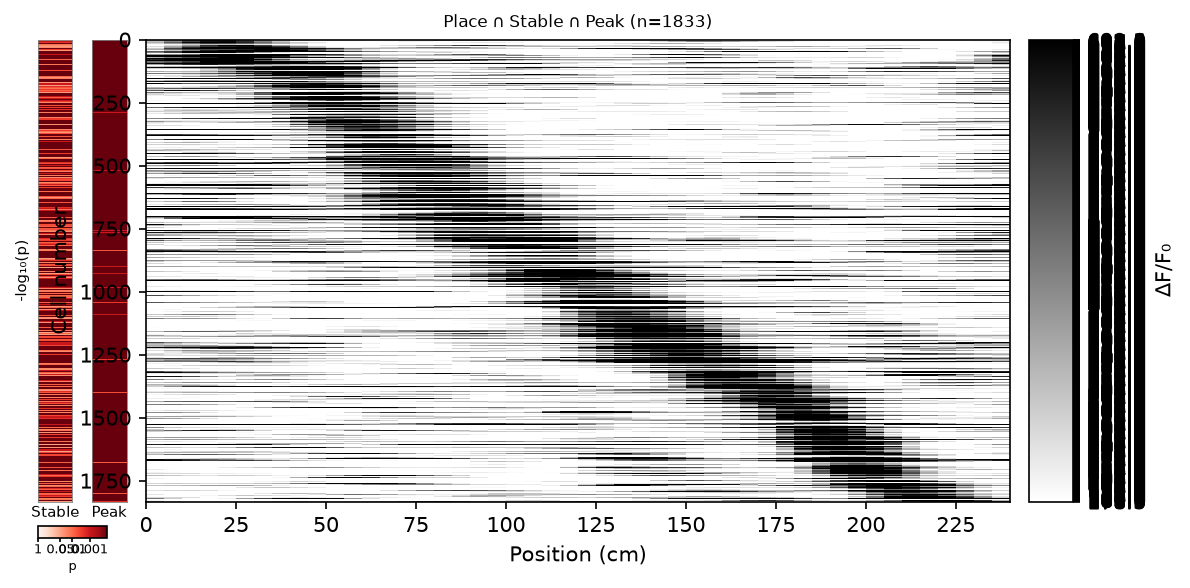

In [52]:
plot_place_cell_heatmap(report=tuning_report, trial_type=trial_type);

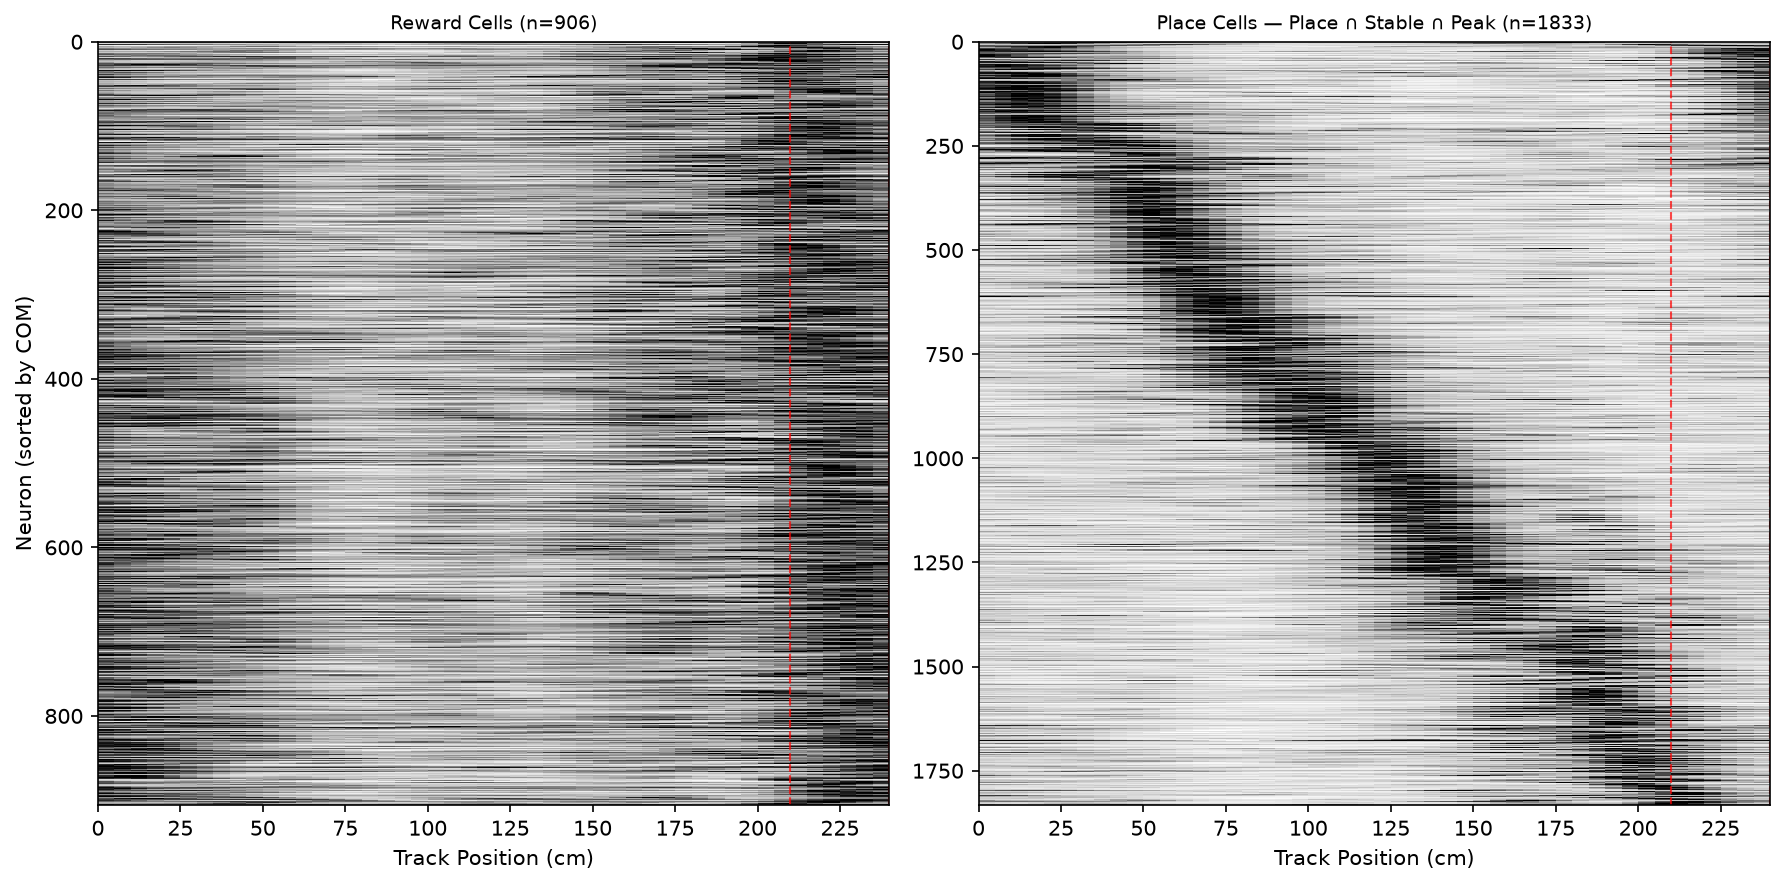

In [53]:
plot_rate_map_heatmap(report=tuning_report, trial_type=trial_type);

In [ ]:
plot_population_activity_by_position(report=tuning_report, trial_type=trial_type);

## 4. Drift (place only)

Computed on the fly via `compute_drift_report` so the configuration can be tuned interactively. Re-run the compute cell after editing `DRIFT_CONFIG`.

In [ ]:
drift_report = compute_drift_report(
    animal=animal,
    sessions=sessions,
    use_bleaching=True,
    configuration=DRIFT_CONFIG,
)

In [ ]:
plot_recurrence_probability_vs_lag(report=drift_report, animal_id=ANIMAL);

In [ ]:
plot_population_vector_correlation_vs_lag(report=drift_report, animal_id=ANIMAL);

In [ ]:
plot_drift_vs_bleaching(report=drift_report, animal_id=ANIMAL);

In [ ]:
plot_sessions_active_distribution(report=drift_report, classifier="place", animal_id=ANIMAL);

In [ ]:
# Per-cell drift profile classification (block-stable / drift-out / drift-in / cycling / mostly-unstable).
plot_drift_profile_categories(report=drift_report, sessions=sessions, animal_id=ANIMAL);

/home/cyberaxolotl/Desktop/GitHubRepos/sollertia-forgery/src/sollertia_forgery/analysis/drift/plotting.py:154: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  .astype(np.float32, copy=False)


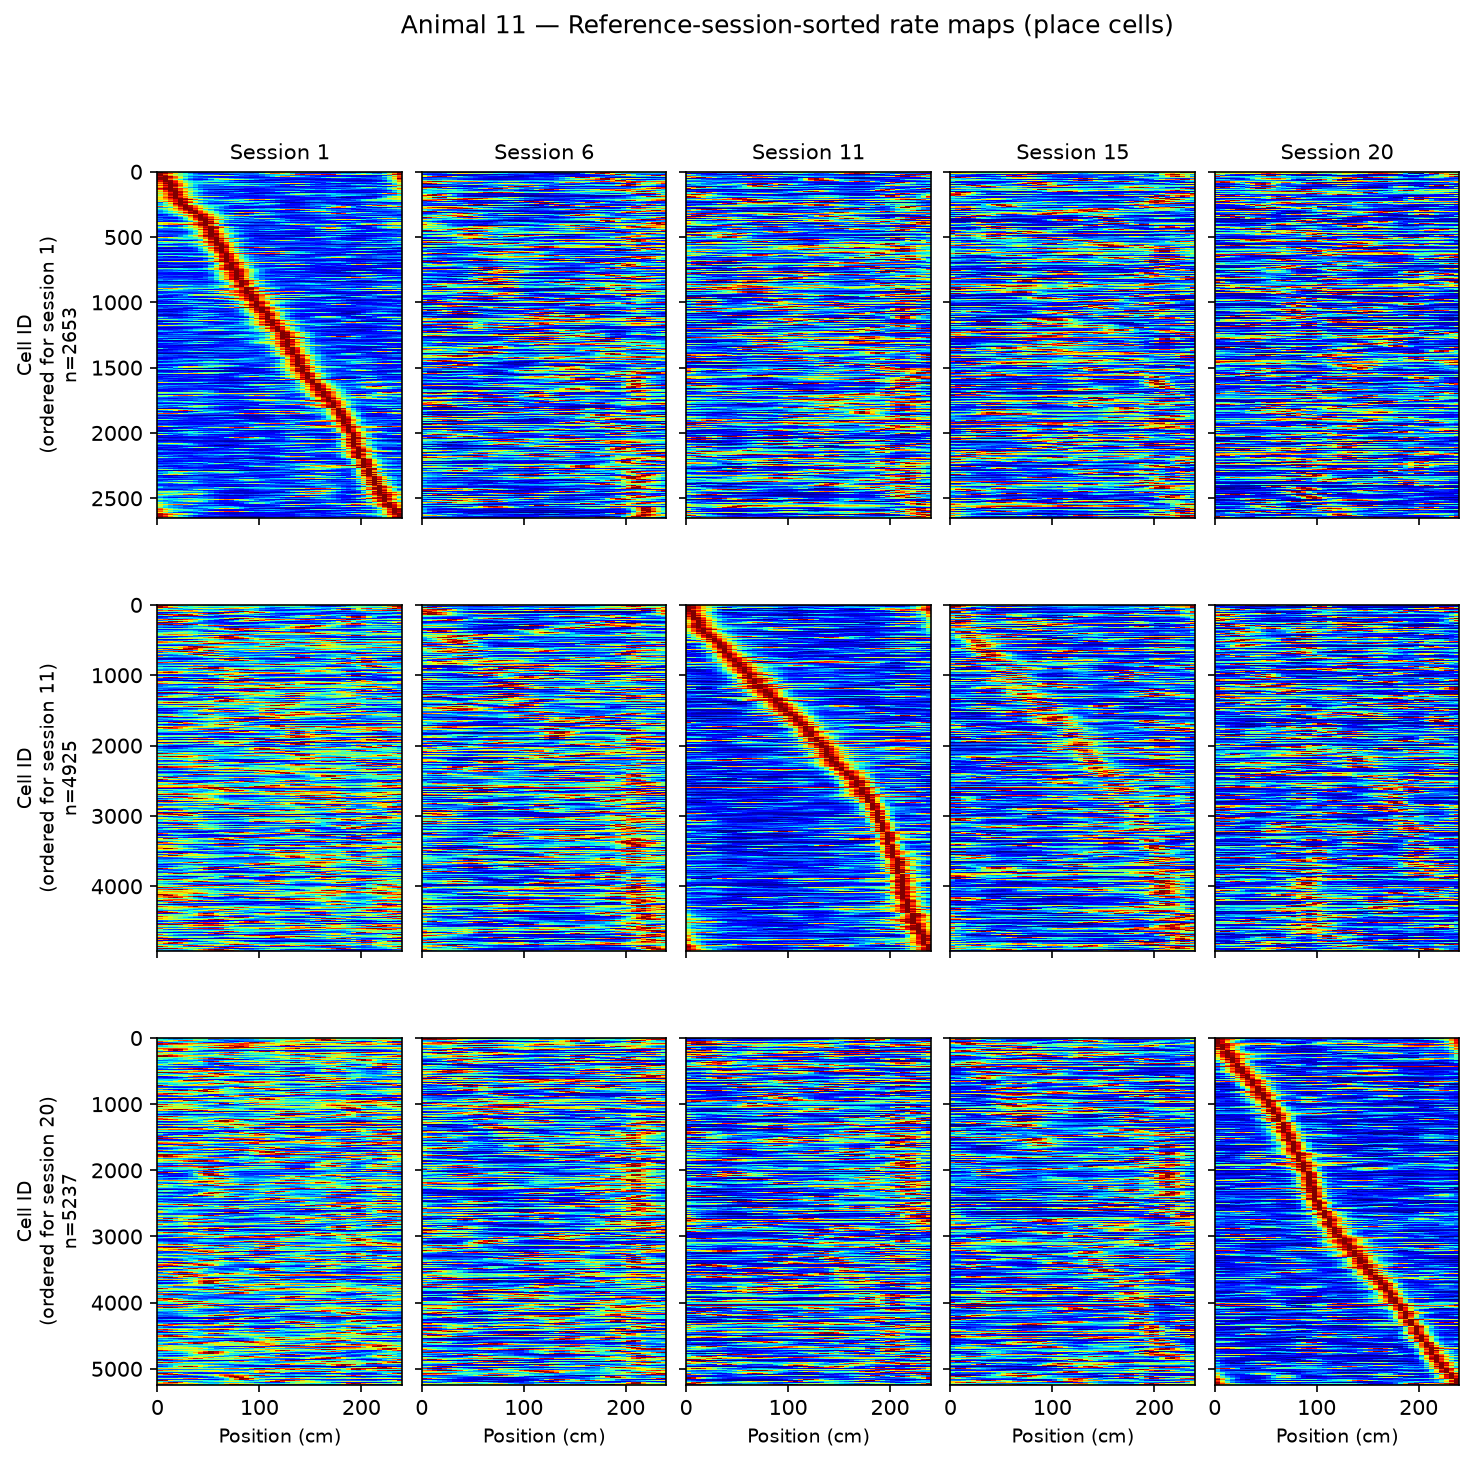

In [51]:
# Defaults to 5 evenly-spaced sessions, sorted by 1st / 3rd / 5th of those.
plot_reference_day_sorted_rate_maps(report=drift_report, sessions=sessions, classifier="place", animal_id=ANIMAL);

## 5. Anchor and reward-shift analysis (from scratchpad 4)

Single-animal versions of the anchor / reward-shift plots originally written for cohort comparisons. Anchor plots use a 15-session window; reward-shift plots use the constants set in section 2. Helpers stay inlined in this notebook so they remain editable during the session.

### 5.1 Helpers

In [ ]:
@dataclass(frozen=True, slots=True)
class TrialBlock:
    """One block of contiguous trials sharing the same reward zone (used by the lick scatter)."""

    cum_trial_start: int
    cum_trial_end: int
    session_index: int
    trial_type: str
    trial_length_cm: float
    reward_lo: float
    reward_hi: float


def compute_anchor_masks(report):
    """Returns (place_anchor, strict_anchor, tuned_place, tuned_strict) bool masks per cell."""
    cells = report.cells
    place_traj = np.asarray(cells[DriftCellColumn.PLACE_TRAJECTORY.value].to_list(), dtype=np.bool_)
    strict_traj = np.asarray(cells[DriftCellColumn.STRICT_PLACE_TRAJECTORY.value].to_list(), dtype=np.bool_)
    is_field_stable = cells[DriftCellColumn.IS_FIELD_STABLE.value].to_numpy()
    is_peak_stable = cells[DriftCellColumn.IS_PEAK_STABLE.value].to_numpy()
    is_clean = ~cells[DriftCellColumn.IS_HIGH_BLEACHING_DRIFT.value].to_numpy()
    place_anchor = place_traj.all(axis=1)
    strict_anchor = strict_traj.all(axis=1)
    tuned_place = place_anchor & is_field_stable & is_peak_stable & is_clean
    tuned_strict = strict_anchor & is_field_stable & is_peak_stable & is_clean
    return place_anchor, strict_anchor, tuned_place, tuned_strict


def column_shuffle_null(trajectory, *, n_iter=200, seed=42):
    """Independence null: shuffle each session's classification column to break per-cell consistency."""
    rng = np.random.default_rng(seed=seed)
    n_cells, n_sessions = trajectory.shape
    counts = np.zeros(n_iter, dtype=np.int64)
    for it in range(n_iter):
        shuffled = np.empty_like(trajectory)
        for j in range(n_sessions):
            shuffled[:, j] = trajectory[rng.permutation(n_cells), j]
        counts[it] = int(shuffled.all(axis=1).sum())
    return counts

### 5.2 Anchor drift context (15-session window)

In [ ]:
anchor_sessions = sessions[:ANCHOR_WINDOW_SESSIONS]
_overrides = {s.session: trial_type for s in anchor_sessions}
anchor_drift_report = compute_drift_report(
    animal=animal,
    sessions=anchor_sessions,
    trial_type_overrides=_overrides,
    use_bleaching=True,
    configuration=DRIFT_CONFIG,
)
place_anchor, strict_anchor, tuned_place_anchor, tuned_strict_anchor = compute_anchor_masks(anchor_drift_report)
anchor_cell_count = anchor_drift_report.summary.cell_count
print(
    f"15-session anchors (animal {ANIMAL}): place={int(place_anchor.sum())}, "
    f"strict={int(strict_anchor.sum())}, tuned_place={int(tuned_place_anchor.sum())}, "
    f"tuned_strict={int(tuned_strict_anchor.sum())}, cells={anchor_cell_count}"
)

### 5.3 Anchor cell counts with chance-null overlay

In [ ]:
def plot_anchor_counts_single(report, masks, animal_id, n_iter=200):
    """4-panel bar chart of anchor counts; place/strict panels overlay column-shuffle null mean."""
    place_m, strict_m, tuned_place_m, tuned_strict_m = masks
    cell_count = report.summary.cell_count
    cells = report.cells
    trajectories = {
        "place": np.asarray(cells[DriftCellColumn.PLACE_TRAJECTORY.value].to_list(), dtype=np.bool_),
        "strict": np.asarray(cells[DriftCellColumn.STRICT_PLACE_TRAJECTORY.value].to_list(), dtype=np.bool_),
    }
    figure, axes = plt.subplots(1, 4, figsize=(14, 4), facecolor="white", dpi=120)
    criteria = [
        (place_m, "place", "Place anchor"),
        (strict_m, "strict", "Strict-place anchor"),
        (tuned_place_m, None, "Tuned place anchor"),
        (tuned_strict_m, None, "Tuned strict-place anchor"),
    ]
    for axis_index, (mask, traj_key, title) in enumerate(criteria):
        axis = axes[axis_index]
        count = int(mask.sum())
        fraction = 100.0 * count / max(cell_count, 1)
        bar = axis.bar([0], [count], color="#1f77b4", edgecolor="black")[0]
        axis.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() + max(count, 1) * 0.01,
            f"{count}\n({fraction:.1f}%)", ha="center", va="bottom", fontsize=9,
        )
        if traj_key is not None:
            null_mean = float(np.mean(column_shuffle_null(trajectories[traj_key], n_iter=n_iter, seed=10)))
            axis.axhline(null_mean, color="black", linestyle="--", linewidth=1.0,
                         label=f"chance null mean = {null_mean:.1f}")
            axis.legend(loc="upper right", frameon=False, fontsize=8)
        axis.set_xticks([0])
        axis.set_xticklabels([f"Animal {animal_id}"])
        axis.set_title(title, fontsize=10)
        axis.set_ylabel("Cell count")
    figure.suptitle(f"Animal {animal_id} — anchor-cell counts ({ANCHOR_WINDOW_SESSIONS}-session window)")
    figure.tight_layout(rect=(0, 0, 1, 0.93))
    return figure


plot_anchor_counts_single(
    anchor_drift_report,
    (place_anchor, strict_anchor, tuned_place_anchor, tuned_strict_anchor),
    animal_id=ANIMAL,
);

### 5.4 Strict-place anchor mean rate maps

In [ ]:
def plot_strict_anchor_rate_maps_single(anchor_sessions, strict_anchor_mask, trial_type, animal_id):
    """Heatmap of strict-place-anchor mean rate maps across the anchor window, sorted by peak."""
    figure, axis = plt.subplots(1, 1, figsize=(6, 7), facecolor="white", dpi=120)
    if not strict_anchor_mask.any():
        axis.text(0.5, 0.5, "no strict anchors", ha="center", va="center", transform=axis.transAxes)
        axis.set_axis_off()
        return figure
    rate_maps_per_session = []
    zone_centers = []
    for s in anchor_sessions:
        tcells = pl.read_ipc(source=s.tuning_cells_path, memory_map=True)
        tcells = tcells.filter(pl.col(TuningColumn.TRIAL_TYPE.value) == trial_type)
        tcells = tcells.sort(TuningColumn.CELL_ID.value)
        rate_maps_per_session.append(np.asarray(tcells[TuningColumn.RATE_MAP.value].to_list(), dtype=np.float32))
        geometry = TrialGeometry.from_yaml(file_path=s.geometry_path)
        entry = geometry.entries.get(trial_type)
        if entry is not None:
            zone_centers.append(0.5 * (entry.stimulus_trigger_zone_start_cm + entry.stimulus_trigger_zone_end_cm))
    stack = np.stack(rate_maps_per_session, axis=0)
    anchor_maps = np.nanmean(stack[:, strict_anchor_mask, :], axis=0)
    peak_bins = np.argmax(anchor_maps, axis=1)
    order = np.argsort(peak_bins)
    normalized = anchor_maps / np.maximum(anchor_maps.max(axis=1, keepdims=True), 1e-6)
    normalized = normalized[order]
    bin_count = stack.shape[2]
    bin_size = TRACK_LENGTH_CM / bin_count
    axis.imshow(normalized, aspect="auto", origin="lower", cmap="viridis",
                extent=[0, bin_count * bin_size, 0, normalized.shape[0]])
    if zone_centers:
        axis.axvline(float(np.mean(zone_centers)), color="orange", linestyle="--", linewidth=1.5,
                     label="reward zone center")
        axis.legend(loc="upper left", frameon=False)
    axis.set_title(f"Animal {animal_id} — strict-place anchor rate maps "
                   f"(n={int(strict_anchor_mask.sum())}, {len(anchor_sessions)} sessions)")
    axis.set_xlabel("Track position (cm)")
    axis.set_ylabel("Strict-place anchor cell (sorted by peak)")
    figure.tight_layout()
    return figure


plot_strict_anchor_rate_maps_single(anchor_sessions, strict_anchor, trial_type, animal_id=ANIMAL);

### 5.5 Top strict-place anchor cells × snapshot sessions

In [ ]:
def plot_strict_anchor_session_grid_single(
    anchor_drift_report, anchor_sessions, strict_anchor_mask, trial_type, animal_id,
    *, top_n=5, snapshot_indices=(0, 5, 10, 14),
):
    """Top-N strict anchors (rows) × snapshot sessions (cols); per-trial fluorescence heatmap per cell."""
    cells = anchor_drift_report.cells
    cell_ids = cells[DriftCellColumn.CELL_ID.value].to_numpy()
    mean_corr = cells[DriftCellColumn.MEAN_RATE_MAP_CORRELATION.value].to_numpy()
    candidate_ids = cell_ids[strict_anchor_mask]
    candidate_corr = mean_corr[strict_anchor_mask]
    finite = np.isfinite(candidate_corr)
    candidate_ids = candidate_ids[finite]
    candidate_corr = candidate_corr[finite]
    if candidate_ids.size == 0:
        figure, axis = plt.subplots(1, 1, figsize=(6, 4), facecolor="white", dpi=120)
        axis.text(0.5, 0.5, "no strict anchors with finite stability", ha="center", va="center",
                  transform=axis.transAxes)
        axis.set_axis_off()
        return figure
    order = np.argsort(-candidate_corr)
    top_ids = candidate_ids[order][:top_n]
    top_corrs = candidate_corr[order][:top_n]
    valid_snapshots = tuple(i for i in snapshot_indices if i < len(anchor_sessions))
    n_rows = top_ids.size

    per_cell_per_session: dict[int, dict[int, np.ndarray | None]] = {int(cid): {} for cid in top_ids}
    for sess_idx in valid_snapshots:
        tcells = pl.read_ipc(source=anchor_sessions[sess_idx].tuning_cells_path, memory_map=True)
        tcells = tcells.filter(pl.col(TuningColumn.TRIAL_TYPE.value) == trial_type)
        tcells = tcells.sort(TuningColumn.CELL_ID.value)
        per_trial_lists = tcells[TuningColumn.BINNED_FLUORESCENCE_PER_TRIAL.value].to_list()
        for cid in top_ids:
            entry = per_trial_lists[int(cid)]
            per_cell_per_session[int(cid)][sess_idx] = (
                np.asarray(entry, dtype=np.float32) if entry else None
            )

    figure, axes = plt.subplots(
        n_rows, len(valid_snapshots), figsize=(3.5 * len(valid_snapshots), 2.2 * n_rows),
        facecolor="black", dpi=120, squeeze=False,
    )
    figure.patch.set_facecolor("black")
    figure.suptitle(
        f"Animal {animal_id} — top {top_n} strict-place anchor tuning across snapshot sessions",
        color="white", fontsize=12,
    )
    for row_index, cid in enumerate(top_ids):
        cid_int = int(cid)
        all_blocks = [
            per_cell_per_session[cid_int][s] for s in valid_snapshots
            if per_cell_per_session[cid_int][s] is not None
        ]
        if all_blocks:
            stack = np.concatenate(all_blocks, axis=0)
            finite_vals = stack[np.isfinite(stack)]
            if finite_vals.size > 0:
                vmin = float(np.percentile(finite_vals, 1))
                vmax = float(np.percentile(finite_vals, 99))
                if vmax <= vmin:
                    vmax = vmin + 1e-3
            else:
                vmin, vmax = 0.0, 1.0
        else:
            vmin, vmax = 0.0, 1.0
        for col_index, sess_idx in enumerate(valid_snapshots):
            axis = axes[row_index, col_index]
            axis.set_facecolor("black")
            for spine in axis.spines.values():
                spine.set_color("white")
            axis.tick_params(colors="white", labelsize=8)
            block = per_cell_per_session[cid_int][sess_idx]
            if block is None or block.size == 0:
                axis.text(0.5, 0.5, "no data", ha="center", va="center",
                          transform=axis.transAxes, color="white", fontsize=9)
                axis.set_xticks([])
                axis.set_yticks([])
                if row_index == 0:
                    axis.set_title(f"session {sess_idx}", color="white")
                continue
            bin_count = block.shape[1]
            bin_size = TRACK_LENGTH_CM / bin_count
            axis.imshow(block, aspect="auto", origin="upper", cmap="jet",
                        interpolation="nearest", vmin=vmin, vmax=vmax,
                        extent=[0, bin_count * bin_size, block.shape[0], 0])
            session_obj = anchor_sessions[sess_idx]
            geometry = TrialGeometry.from_yaml(file_path=session_obj.geometry_path)
            entry = geometry.entries.get(trial_type)
            if entry is not None:
                axis.axvspan(entry.stimulus_trigger_zone_start_cm, entry.stimulus_trigger_zone_end_cm,
                             color="orange", alpha=0.2)
            if row_index == 0:
                axis.set_title(f"session {sess_idx}", color="white")
            if col_index == 0:
                axis.set_ylabel(f"cell {cid_int}\nr={top_corrs[row_index]:.2f}", color="white", fontsize=9)
            if row_index == n_rows - 1:
                axis.set_xlabel("Position (cm)", color="white", fontsize=9)
            else:
                axis.set_xticklabels([])
    figure.tight_layout(rect=(0, 0, 1, 0.95))
    return figure


plot_strict_anchor_session_grid_single(
    anchor_drift_report, anchor_sessions, strict_anchor, trial_type, animal_id=ANIMAL,
);

### 5.6 Lick events across all sessions

In [ ]:
def aggregate_lick_data(sessions_in):
    """Returns (lick_positions, lick_trials, blocks, boundaries, total_trials, max_track_length)."""
    cum = 0
    boundaries = [0]
    blocks: list[TrialBlock] = []
    pos_chunks: list[np.ndarray] = []
    trial_chunks: list[np.ndarray] = []
    track_max = 0.0
    for sess_idx, sess in enumerate(sessions_in):
        geometry = TrialGeometry.from_yaml(file_path=sess.geometry_path)
        df = pl.read_ipc(
            source=sess.session_path / "data.feather",
            columns=["system_state", "lick", "distance_cm", "trial", "trial_type"],
            memory_map=True,
        )
        run = df.filter((pl.col("system_state") == "run") & (pl.col("trial") < 255))
        if run.height == 0:
            boundaries.append(cum)
            continue
        distance = run["distance_cm"].to_numpy()
        trials_arr = run["trial"].to_numpy()
        licks = run["lick"].to_numpy().astype(np.int8)
        tt_list = run["trial_type"].to_list()
        position = np.zeros_like(distance, dtype=np.float64)
        in_session_idx = np.zeros_like(trials_arr, dtype=np.int64)
        seen_trials = [int(trials_arr[0])]
        seen_tt = [tt_list[0]]
        current_trial = trials_arr[0]
        start_distance = distance[0]
        for i in range(distance.shape[0]):
            if trials_arr[i] != current_trial:
                current_trial = int(trials_arr[i])
                start_distance = distance[i]
                seen_trials.append(current_trial)
                seen_tt.append(tt_list[i])
            in_session_idx[i] = len(seen_trials) - 1
            position[i] = distance[i] - start_distance
        n_trials = len(seen_trials)
        per_trial = []
        for ti in range(n_trials):
            tt_name = seen_tt[ti]
            entry = geometry.entries.get(tt_name)
            if entry is None:
                per_trial.append({"reward_lo": float("nan"), "reward_hi": float("nan"),
                                  "trial_length_cm": TRACK_LENGTH_CM, "trial_type": tt_name})
            else:
                per_trial.append({
                    "reward_lo": float(entry.stimulus_trigger_zone_start_cm),
                    "reward_hi": float(entry.stimulus_trigger_zone_end_cm),
                    "trial_length_cm": float(entry.trial_length_cm),
                    "trial_type": tt_name,
                })
        zone_keys = [(p["reward_lo"], p["reward_hi"], p["trial_type"], p["trial_length_cm"])
                     for p in per_trial]
        for key, group in groupby(enumerate(zone_keys), key=lambda kv: kv[1]):
            indices = [item[0] for item in group]
            blocks.append(TrialBlock(
                cum_trial_start=cum + indices[0], cum_trial_end=cum + indices[-1] + 1,
                session_index=sess_idx, trial_type=key[2], trial_length_cm=key[3],
                reward_lo=key[0], reward_hi=key[1],
            ))
        track_max = max(track_max, max(p["trial_length_cm"] for p in per_trial))
        trial_lengths = np.array([per_trial[ti]["trial_length_cm"] for ti in in_session_idx])
        wrapped = np.mod(position, trial_lengths)
        rising = np.diff(np.concatenate([[0], licks])) == 1
        lp = wrapped[rising].astype(np.float32)
        lt = in_session_idx[rising].astype(np.int64) + cum
        if lp.size > 0:
            pos_chunks.append(lp)
            trial_chunks.append(lt)
        cum += n_trials
        boundaries.append(cum)
    if pos_chunks:
        all_pos = np.concatenate(pos_chunks)
        all_trials = np.concatenate(trial_chunks)
    else:
        all_pos = np.zeros(0, dtype=np.float32)
        all_trials = np.zeros(0, dtype=np.int64)
    return all_pos, all_trials, blocks, boundaries, cum, (track_max if track_max > 0 else TRACK_LENGTH_CM)


def plot_lick_scatter_single(sessions_in, animal_id):
    """Per-trial-resolved lick scatter across every session for one animal."""
    all_pos, all_trials, blocks, boundaries, total_trials, track_max = aggregate_lick_data(sessions_in)
    if total_trials == 0:
        figure, axis = plt.subplots(1, 1, figsize=(8, 4), facecolor="white", dpi=120)
        axis.text(0.5, 0.5, "zero trials", ha="center", va="center", transform=axis.transAxes)
        axis.set_axis_off()
        return figure
    figure, axis = plt.subplots(
        1, 1, figsize=(10, max(6.0, 0.025 * total_trials + 3.0)),
        facecolor="white", dpi=120,
    )
    for block in blocks:
        height = block.cum_trial_end - block.cum_trial_start
        if block.trial_length_cm < track_max:
            axis.add_patch(Rectangle(
                (block.trial_length_cm, block.cum_trial_start),
                track_max - block.trial_length_cm, height,
                facecolor="#cccccc", edgecolor="#888888", alpha=0.55,
                hatch="///", linewidth=0.0, zorder=0,
            ))
        if not np.isfinite(block.reward_lo) or not np.isfinite(block.reward_hi):
            continue
        axis.add_patch(Rectangle(
            (block.reward_lo, block.cum_trial_start),
            block.reward_hi - block.reward_lo, height,
            facecolor="#a6c8e5", edgecolor="none", alpha=0.45, zorder=0,
        ))
    axis.scatter(all_pos, all_trials, s=3, color="#c2185b", alpha=0.55,
                 edgecolor="none", zorder=2)
    for boundary in boundaries[1:-1]:
        axis.axhline(boundary, color="gray", linestyle="--", linewidth=0.6, zorder=1)
    axis.set_xlim(0, track_max)
    axis.set_ylim(total_trials, 0)
    axis.set_xlabel("Position (cm)")
    axis.set_ylabel("Trial number (chronological across sessions)")
    axis.set_title(
        f"Animal {animal_id} — lick events across {len(sessions_in)} sessions "
        f"({total_trials} trials, {all_pos.size} lick events)"
    )
    legend_handles = [
        plt.Line2D([0], [0], marker="o", color="none", markerfacecolor="#c2185b",
                   markersize=7, label="Lick events"),
        Patch(facecolor="#a6c8e5", edgecolor="black", linewidth=0.6, label="Reward zone"),
        plt.Line2D([0], [0], color="gray", linestyle="--", linewidth=0.7, label="Session separator"),
    ]
    axis.legend(handles=legend_handles, loc="upper left", bbox_to_anchor=(1.02, 1.0),
                borderaxespad=0.0, frameon=False, fontsize=9)
    figure.tight_layout(rect=(0, 0, 0.85, 1.0))
    return figure


plot_lick_scatter_single(sessions, animal_id=ANIMAL);

### 5.7 Pre-shift future-reward-tuned cells

In [ ]:
def plot_pre_shift_future_reward_cells(anchor_drift_report, sessions_in, animal_id, panel_sessions=PANEL_SESSIONS):
    """Pre-shift stable place cells whose pre-shift mean peak sits in the NEW reward zone.

    Mirrors scratchpad_5.render_bw: sorts the selected cells by pre-shift peak and renders one panel per
    session in ``panel_sessions`` (typically the last pre-shift session through every available post-shift
    session). Active reward zone is drawn red-dashed; inactive zone is gray-dotted.
    """
    cells = anchor_drift_report.cells
    cell_ids = cells[DriftCellColumn.CELL_ID.value].to_numpy()
    stable_place = cells[DriftCellColumn.IS_STABLY_TUNED_PLACE.value].to_numpy()
    new_reward_center = 0.5 * (NEW_REWARD_LO + NEW_REWARD_HI)

    rate_maps_per_panel: dict[int, np.ndarray] = {}
    bin_count_ref: int | None = None
    for s_idx in (*PRE_SHIFT_SESSIONS, *panel_sessions):
        if s_idx in rate_maps_per_panel or s_idx >= len(sessions_in):
            continue
        sc = pl.read_ipc(source=sessions_in[s_idx].tuning_cells_path, memory_map=True)
        sc = sc.sort(TuningColumn.CELL_ID.value)
        rate_maps_per_panel[s_idx] = np.asarray(sc[TuningColumn.RATE_MAP.value].to_list(), dtype=np.float32)
        if bin_count_ref is None:
            bin_count_ref = rate_maps_per_panel[s_idx].shape[1]
    bin_count = bin_count_ref or 0
    bin_size = TRACK_LENGTH_CM / max(bin_count, 1)

    pre_stack = np.stack(
        [rate_maps_per_panel[s] for s in PRE_SHIFT_SESSIONS if s in rate_maps_per_panel], axis=0,
    )
    mean_pre = np.nanmean(pre_stack, axis=0)
    finite_mean = np.where(np.isfinite(mean_pre), mean_pre, -np.inf)
    peak_bins = np.argmax(finite_mean, axis=1)
    peak_positions = (peak_bins + 0.5) * bin_size
    max_pre = np.nanmax(mean_pre, axis=1)
    has_activity = np.isfinite(max_pre) & (max_pre > 0)
    near_new = has_activity & (np.abs(peak_positions - new_reward_center) <= PROXIMITY_CM)

    sel = stable_place & near_new
    ids_sel = cell_ids[sel]
    peaks_sel = peak_positions[sel]
    sorted_ids = ids_sel[np.argsort(peaks_sel)]
    n_total = sorted_ids.size

    valid_panels = tuple(s for s in panel_sessions if s in rate_maps_per_panel)
    figure, axes = plt.subplots(
        1, max(len(valid_panels), 1),
        figsize=(4 * max(len(valid_panels), 1), 7), facecolor="white", dpi=120,
        gridspec_kw={"wspace": 0.05}, squeeze=False,
    )
    axes = axes[0]
    if n_total == 0:
        axes[0].text(0.5, 0.5, "no pre-shift stable place cells tuned to NEW reward zone",
                     ha="center", va="center", transform=axes[0].transAxes)
        for ax in axes:
            ax.set_axis_off()
        return figure
    for axis_index, sess_idx in enumerate(valid_panels):
        axis = axes[axis_index]
        selected_maps = rate_maps_per_panel[sess_idx][sorted_ids]
        finite_max = np.nanmax(selected_maps, axis=1, keepdims=True)
        finite_max = np.where(np.isfinite(finite_max) & (finite_max > 0), finite_max, 1.0)
        intensities = np.clip(selected_maps / finite_max, 0.0, 1.0)
        intensities = np.where(np.isfinite(intensities), intensities, 0.0)
        post_shift = sess_idx >= SHIFT_AT_SESSION
        rz_lo, rz_hi = (NEW_REWARD_LO, NEW_REWARD_HI) if post_shift else (OLD_REWARD_LO, OLD_REWARD_HI)
        block_label = "POST-SHIFT" if post_shift else "PRE-SHIFT"
        axis.imshow(intensities, aspect="auto", origin="upper", cmap="gray_r",
                    extent=[0, bin_count * bin_size, n_total, 0], vmin=0, vmax=1)
        axis.axvline(rz_lo, color="red", linestyle="--", linewidth=1.5)
        axis.axvline(rz_hi, color="red", linestyle="--", linewidth=1.5)
        if post_shift:
            axis.axvline(OLD_REWARD_LO, color="gray", linestyle=":", linewidth=0.8)
            axis.axvline(OLD_REWARD_HI, color="gray", linestyle=":", linewidth=0.8)
        else:
            axis.axvline(NEW_REWARD_LO, color="gray", linestyle=":", linewidth=0.8)
            axis.axvline(NEW_REWARD_HI, color="gray", linestyle=":", linewidth=0.8)
        axis.set_title(f"session {sess_idx}  ({block_label})", fontsize=10)
        axis.set_xlabel("Track Position (cm)", fontsize=9)
        axis.set_xlim(0, TRACK_LENGTH_CM)
        if axis_index == 0:
            axis.set_ylabel(f"Stable place cell tuned to NEW zone\n(sorted by pre-shift peak, n={n_total})",
                            fontsize=9)
    figure.suptitle(
        f"Animal {animal_id} — PRE-shift stable PLACE cells already tuned to NEW reward zone\n"
        f"red dashed = active reward zone; gray dotted = inactive reward zone", fontsize=11,
    )
    figure.tight_layout(rect=(0, 0, 1, 0.92))
    return figure


plot_pre_shift_future_reward_cells(anchor_drift_report, sessions, animal_id=ANIMAL);

## 6. Free-form exploration

Use the loaded `dataset`, `animal`, `sessions`, `session`, `tuning_report`, `drift_report`, `anchor_drift_report`, and the four anchor masks (`place_anchor`, `strict_anchor`, `tuned_place_anchor`, `tuned_strict_anchor`) for ad-hoc analyses below.